In [2]:
!pip install dgl -f https://data.dgl.ai/wheels/cu121/repo.html --force-reinstall
!pip install dgllife rdkit selfies tqdm torchdata

!echo "" > /usr/local/lib/python3.12/dist-packages/dgl/graphbolt/base.py
!echo "" > /usr/local/lib/python3.12/dist-packages/dgl/graphbolt/__init__.py
!sed -i 's/graphbolt as gb, //g' /usr/local/lib/python3.12/dist-packages/dgl/distributed/dist_graph.py

Looking in links: https://data.dgl.ai/wheels/cu121/repo.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 467.5/467.5 MB 3.9 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 39.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 87.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 52.5 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
!wget https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py -O /kaggle/working/sascorer.py
!wget https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz -O /kaggle/working/fpscores.pkl.gz

--2026-06-08 12:19:57--  https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/sascorer.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 5913 (5.8K) [text/plain]
Saving to: ‘/kaggle/working/sascorer.py’

/kaggle/working/sas 100%[===================>]   5.77K  --.-KB/s    in 0s      

2026-06-08 12:19:57 (51.9 MB/s) - ‘/kaggle/working/sascorer.py’ saved [5913/5913]

--2026-06-08 12:19:57--  https://raw.githubusercontent.com/rdkit/rdkit/master/Contrib/SA_Score/fpscores.pkl.gz
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK

In [5]:
import os
os.environ["DGL_DISABLE_GRAPHBOLT"] = "1"

import os
import pickle
import torch
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import sascorer
from collections import defaultdict
from multiprocessing import Pool
from torch.utils.data import DataLoader, Dataset
from tqdm.notebook import tqdm
from sklearn.model_selection import train_test_split
from dgllife.utils.jtvae.vocab import JTVAEVocab
from dgllife.utils.jtvae.mol_tree import MolTree
from dgllife.data.jtvae import JTVAEDataset, JTVAECollator
from dgllife.model.model_zoo.jtvae import JTNNVAE
from rdkit import Chem
from rdkit.Chem import Draw, AllChem, DataStructs, rdmolops, Descriptors, rdMolDescriptors, QED
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator

from rdkit import Chem

torch.cuda.empty_cache()

DGL backend not selected or invalid.  Assuming PyTorch for now.


Setting the default backend to "pytorch". You can change it in the ~/.dgl/config.json file or export the DGLBACKEND environment variable.  Valid options are: pytorch, mxnet, tensorflow (all lowercase)


In [25]:
df = pd.read_csv('/kaggle/input/datasets/volqano/smiles/smiles_selfies_full.csv')

In [27]:
df = df.sample(frac=0.015, random_state=42).reset_index(drop=True)

In [28]:
len(df)

11916

In [47]:
# smiles dataset preprocessing and building vocab (dont run if you already have vocab in pickle)
def check_single_smiles(smiles):
    try:
        t = MolTree(smiles)
        t.recover()
        t.assemble()
        
        return smiles, True
    except Exception:
        return smiles, False

raw_smiles = df['smiles'].tolist()
num_cores = os.cpu_count()

clean_smiles_list = []
bad_smiles_count = 0

with Pool(processes=num_cores) as pool:
    results = list(tqdm(pool.imap(check_single_smiles, raw_smiles), total=len(raw_smiles), desc="Filtrowanie równoległe"))

for smiles, is_ok in results:
    if is_ok:
        clean_smiles_list.append(smiles)
    else:
        bad_smiles_count += 1

print(f"Bad smiles count: {bad_smiles_count}")
print(f"Clean smiles count: {len(clean_smiles_list)}")

temp_smiles_path = '/kaggle/working/temp_smiles_for_vocab.txt'
with open(temp_smiles_path, 'w') as f:
    for smiles in clean_smiles_list:
        f.write(f"{smiles}\n")

vocab = JTVAEVocab(temp_smiles_path)

with open('/kaggle/working/jt_vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)

if os.path.exists(temp_smiles_path):
    os.remove(temp_smiles_path)

Filtrowanie równoległe:   0%|          | 0/11916 [00:00<?, ?it/s]

Bad smiles count: 574
Clean smiles count: 11342


In [ ]:
vocab = JTVAEVocab(temp_smiles_path)

with open('/kaggle/working/jt_vocab.pkl', 'wb') as f:
    pickle.dump(vocab, f)
print("Słownik Vocab zapisany pomyślnie!")

In [48]:
# split dataset
smiles_train, smiles_temp = train_test_split(clean_smiles_list, test_size=0.2, random_state=42, shuffle=True)
smiles_val, smiles_test = train_test_split(smiles_temp, test_size=0.5, random_state=42, shuffle=True)

# we save to file because this model is so awfully written, that it cannot read strings :)
train_txt = '/kaggle/working/train_smiles.txt'
val_txt = '/kaggle/working/val_smiles.txt'
test_txt = '/kaggle/working/test_smiles.txt'

def save_to_txt(smiles_list, file_path):
    with open(file_path, 'w') as f:
        for smiles in smiles_list:
            f.write(f"{smiles}\n")

save_to_txt(smiles_train, train_txt)
save_to_txt(smiles_val, val_txt)
save_to_txt(smiles_test, test_txt)
print("pozdro")
train_dataset = JTVAEDataset(train_txt, vocab)
val_dataset = JTVAEDataset(val_txt, vocab)
test_dataset = JTVAEDataset(test_txt, vocab)

pozdro


In [49]:
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

In [50]:
# training
latent_dim = 256
hidden_dim = 450
depth = 3
model = JTNNVAE(
    vocab=vocab,
    hidden_size=hidden_dim,
    latent_size=latent_dim,
    depth=depth
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

beta = 0.005
num_epochs = 4
history = {
    'train_loss': [], 
    'word_loss': [], 
    'topo_loss': [], 
    'bond_loss': [], 
    'atom_loss': [], 
    'kl_loss': [], 
    'val_loss': []
}

collator = JTVAECollator(vocab)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collator)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=collator)

best_val_loss = float('inf')

for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0
    total_word_loss = 0
    total_topo_loss = 0
    total_bond_loss = 0
    total_atom_loss = 0
    total_kl_loss = 0
    
    pbar = tqdm(train_loader)
    for batch in pbar:
        optimizer.zero_grad()
        batch = [g.to(device) if hasattr(g, 'to') else g for g in batch]
        loss, kl_l, word_l, topo_l, bond_l, atom_l = model(*batch, beta=beta)
        
        loss.backward()
        optimizer.step()

        pbar.set_postfix({
            "wrd": f"{word_l:.2f}",
            "top": f"{topo_l:.2f}",
            "bnd": f"{bond_l:.2f}",
            "atm": f"{atom_l:.2f}",
            "kl": f"{kl_l:.2f}",
            "tot": f"{loss.item():.2f}",
        })

        total_loss += loss.item()
        total_word_loss += word_l
        total_topo_loss += topo_l
        total_bond_loss += bond_l
        total_atom_loss += atom_l
        total_kl_loss += kl_l

    with torch.no_grad():
        model.eval()
        val_loss = 0
        for batch in val_loader:
            batch = [g.to(device) if hasattr(g, 'to') else g for g in batch]
            loss, _, _, _, _, _ = model(*batch, beta=beta)
            val_loss += loss.item()

    total_loss /= len(train_loader)
    total_word_loss /= len(train_loader)
    total_topo_loss /= len(train_loader)
    total_bond_loss /= len(train_loader)
    total_atom_loss /= len(train_loader)
    total_kl_loss /= len(train_loader)
    val_loss /= len(val_loader)

    if val_loss < best_val_loss:
        MODEL_PATH = '/kaggle/working/best_jt_vae_baseline.pt'
        torch.save(model.state_dict(), MODEL_PATH)
        best_val_loss = val_loss

    history['train_loss'].append(total_loss)
    history['word_loss'].append(total_word_loss)
    history['topo_loss'].append(total_topo_loss)
    history['bond_loss'].append(total_bond_loss)
    history['atom_loss'].append(total_atom_loss)
    history['kl_loss'].append(total_kl_loss)
    history['val_loss'].append(val_loss)
    
    print(f"Epoch {epoch}/{num_epochs} - Train: {total_loss:.4f} | Val: {val_loss:.4f}")
    print(f" > Składowe: Word: {total_word_loss:.4f}, Topo: {total_topo_loss:.4f}, Bond: {total_bond_loss:.4f}, Atom: {total_atom_loss:.4f}, KL: {total_kl_loss:.4f}")

  0%|          | 0/284 [00:00<?, ?it/s]

Epoch 1/4 - Train: 36.8226 | Val: 29.4696
 > Składowe: Word: 0.5670, Topo: 0.8917, Bond: 0.5848, Atom: 0.4155, KL: 129.3610


  0%|          | 0/284 [00:00<?, ?it/s]

Epoch 2/4 - Train: 27.0686 | Val: 26.1547
 > Składowe: Word: 0.6920, Topo: 0.9310, Bond: 0.6238, Atom: 0.4519, KL: 159.1610


  0%|          | 0/284 [00:00<?, ?it/s]

Epoch 3/4 - Train: 23.4702 | Val: 23.5563
 > Składowe: Word: 0.7328, Topo: 0.9431, Bond: 0.6452, Atom: 0.4160, KL: 180.0543


  0%|          | 0/284 [00:00<?, ?it/s]

Epoch 4/4 - Train: 20.6806 | Val: 22.4463
 > Składowe: Word: 0.7641, Topo: 0.9519, Bond: 0.6764, Atom: 0.3888, KL: 202.4761


In [ ]:
# loading model (run if trained before)
latent_dim = 56
hidden_dim = 450
depth = 3

model = JTNNVAE(
    vocab=vocab,
    hidden_size=hidden_dim,
    latent_size=latent_dim,
    depth=depth
).to(device)

MODEL_PATH = '/kaggle/working/best_jt_vae_baseline.pt'

if os.path.exists(MODEL_PATH):
    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    model.eval()
    print("Model loaded successfully")
else:
    print(f"ERROR: File {MODEL_PATH} does not exist")

In [51]:
# utils
def get_molecule_properties(mol):
    return {
        "molWt": Descriptors.MolWt(mol),
        "HeavyAtomCount": mol.GetNumHeavyAtoms(),
        "cLogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "HBD": rdMolDescriptors.CalcNumHBD(mol),
        "HBA": rdMolDescriptors.CalcNumHBA(mol),
        "NumRotatableBonds": rdMolDescriptors.CalcNumRotatableBonds(mol),
        "RingCount": rdMolDescriptors.CalcNumRings(mol),
        "AromaticRingCount": rdMolDescriptors.CalcNumAromaticRings(mol),
        "FractionCSP3": rdMolDescriptors.CalcFractionCSP3(mol),
        "NumSpiroAtoms": rdMolDescriptors.CalcNumSpiroAtoms(mol),
        "NumBridgeheadAtoms": rdMolDescriptors.CalcNumBridgeheadAtoms(mol),
        "BertzCT": Descriptors.BertzCT(mol),
        "QED": QED.qed(mol),
        "SA-score": sascorer.calculateScore(mol)
    }

def compute_property(mol, name):
    if name == "molWt":
        return Descriptors.MolWt(mol)
    elif name == "HeavyAtomCount":
        return mol.GetNumHeavyAtoms()
    elif name == "cLogP":
        return Descriptors.MolLogP(mol)
    elif name == "TPSA":
        return Descriptors.TPSA(mol)
    elif name == "HBD":
        return rdMolDescriptors.CalcNumHBD(mol)
    elif name == "HBA":
        return rdMolDescriptors.CalcNumHBA(mol)
    elif name == "NumRotatableBonds":
        return rdMolDescriptors.CalcNumRotatableBonds(mol)
    elif name == "RingCount":
        return rdMolDescriptors.CalcNumRings(mol)
    elif name == "AromaticRingCount":
        return rdMolDescriptors.CalcNumAromaticRings(mol)
    elif name == "FractionCSP3":
        return rdMolDescriptors.CalcFractionCSP3(mol)
    elif name == "NumSpiroAtoms":
        return rdMolDescriptors.CalcNumSpiroAtoms(mol)
    elif name == "NumBridgeheadAtoms":
        return rdMolDescriptors.CalcNumBridgeheadAtoms(mol)
    elif name == "BertzCT":
        return Descriptors.BertzCT(mol)
    elif name == "QED":
        return QED.qed(mol)
    elif name == "SA-score":
        return sascorer.calculateScore(mol)
    else:
        return np.nan

def latents_to_mol(model, z):
    model.eval()
    
    half_dim = z.size(-1) // 2
    tree_vecs = z[:, :half_dim]
    mol_vecs = z[:, half_dim:]
    
    mols = []
    
    for i in tqdm(range(z.size(0)), desc="Dekodowanie cząsteczek"):
        t_v = tree_vecs[i:i+1]
        m_v = mol_vecs[i:i+1]
        
        try:
            with torch.no_grad():
                smile_list = model.decode(t_v, m_v, prob_decode=False)
            
            smile = smile_list[0]
            
            if smile is None:
                mols.append(None)
                continue
                
            mol = Chem.MolFromSmiles(smile)
            mols.append(mol)
            
        except Exception as e:
            mols.append(None)
            
    return mols

In [53]:
n_samples = 5000

z = torch.randn(
    n_samples,
    latent_dim,
    device=device
)

mols = latents_to_mol(model, z)

Dekodowanie cząsteczek:   0%|          | 0/5000 [00:00<?, ?it/s]

In [54]:
valid_mols = [m for m in mols if m is not None]

print("Generated:", len(mols))
print("Valid:", len(valid_mols))
print("Validity:", len(valid_mols) / len(mols))

Generated: 5000
Valid: 4985
Validity: 0.997


In [55]:
Sampled_properties = []

for mol in tqdm(valid_mols):
    try:
        Sampled_properties.append(get_molecule_properties(mol))
    except Exception as e:
        print(e)

  0%|          | 0/4985 [00:00<?, ?it/s]

In [54]:
smiles_list = df["smiles"]

Y = []
valid = 0

for mol in tqdm((Chem.MolFromSmiles(s) for s in smiles_list),
                total=len(smiles_list),
                desc="Computing properties"):

    if mol is None:
        continue

    Y.append(get_molecule_properties(mol))
    valid += 1

Y = pd.DataFrame(Y)

print("Valid:", valid)

Computing properties:   0%|          | 0/794403 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [56]:
Y = pd.read_csv('/kaggle/input/datasets/volqano/molecule-properties/molecule_properties.csv')

In [57]:
Y.head()

,molWt,HeavyAtomCount,cLogP,TPSA,HBD,HBA,NumRotatableBonds,RingCount,AromaticRingCount,FractionCSP3,NumSpiroAtoms,NumBridgeheadAtoms,BertzCT,QED,SA-score
0,428.334,29,4.63520,55.76,1,3,3,4,3,0.052632,0,0,1116.076710,0.488175,3.486284
1,396.494,30,4.28340,61.02,2,4,4,5,4,0.200000,0,0,1263.133288,0.540433,3.326125
2,489.757,30,3.45420,98.32,3,4,5,4,3,0.190476,0,0,1152.359030,0.478160,3.162661
3,451.243,25,2.79190,55.95,0,3,3,4,3,0.235294,0,0,917.523590,0.576130,2.680019
4,340.810,24,4.25532,44.12,0,3,5,3,3,0.157895,0,0,843.582943,0.514753,2.262954


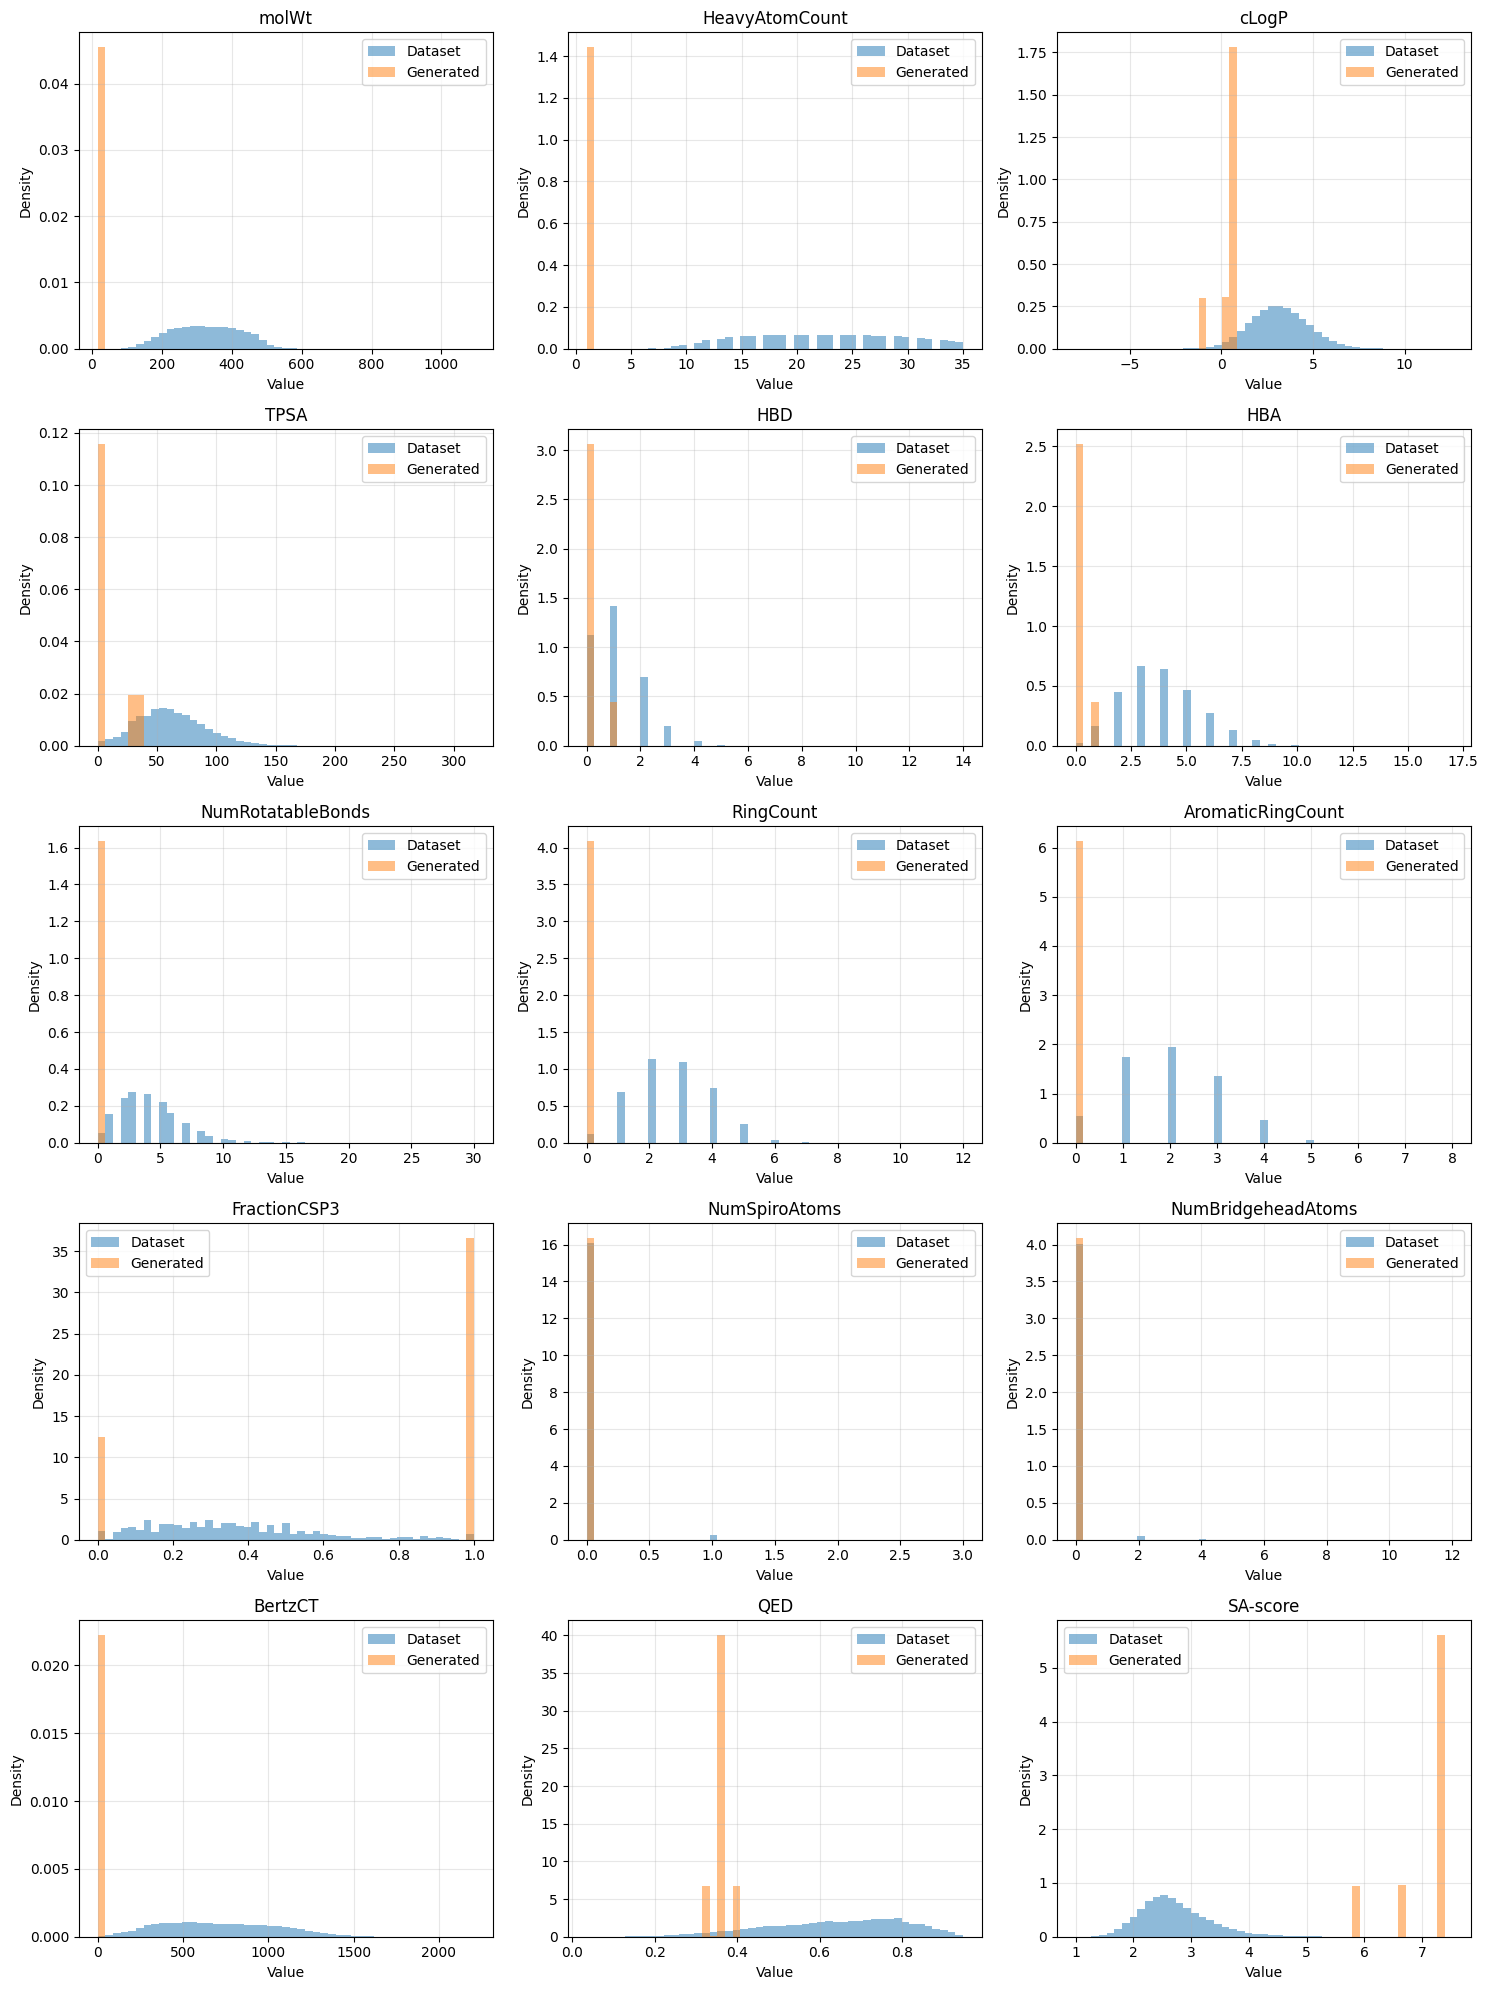

In [58]:
# plots
prop_dict = defaultdict(list)

for props in Sampled_properties:
    if props is None:
        continue
    for k, v in props.items():
        if v is not None and not np.isnan(v):
            prop_dict[k].append(v)

cols = Y.columns
n_cols = len(cols)

n_rows = math.ceil(n_cols / 3)
n_cols_grid = 3

fig, axes = plt.subplots(n_rows, n_cols_grid, figsize=(5 * n_cols_grid, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cols):
    gen_vals = prop_dict.get(col, [])

    if len(gen_vals) == 0:
        continue

    data_vals = Y[col].dropna()

    combined = np.concatenate([data_vals.values, gen_vals])
    bins = np.linspace(combined.min(), combined.max(), 50)

    axes[i].hist(data_vals, bins=bins, alpha=0.5, label="Dataset", density=True)
    axes[i].hist(gen_vals, bins=bins, alpha=0.5, label="Generated", density=True)

    axes[i].set_title(col)
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Density")
    axes[i].grid(alpha=0.3)
    axes[i].legend()

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [59]:
def compute_generation_metrics(mols, train_smiles_set):
    valid_mols = [m for m in mols if m is not None]
    validity = len(valid_mols) / len(mols) if len(mols) > 0 else 0

    smiles = []
    for m in valid_mols:
        try:
            s = Chem.MolToSmiles(m, canonical=True)
            smiles.append(s)
        except:
            pass

    unique_smiles = set(smiles)
    uniqueness = len(unique_smiles) / len(smiles) if len(smiles) > 0 else 0

    novel_smiles = [s for s in unique_smiles if s not in train_smiles_set]
    novelty = len(novel_smiles) / len(unique_smiles) if len(unique_smiles) > 0 else 0

    return {
        "validity": validity,
        "uniqueness": uniqueness,
        "novelty": novelty,
        "n_valid": len(valid_mols),
        "n_unique": len(unique_smiles),
        "n_novel": len(novel_smiles),
    }

In [60]:
train_smiles_set = set(df["smiles"].dropna().tolist())
metrics = compute_generation_metrics(mols, train_smiles_set)

print("Validity:", metrics["validity"])
print("Uniqueness:", metrics["uniqueness"])
print("Novelty:", metrics["novelty"])
print("Valid:", metrics["n_valid"])
print("Unique:", metrics["n_unique"])
print("Novel:", metrics["n_novel"])

Validity: 0.997
Uniqueness: 0.0008024072216649949
Novelty: 1.0
Valid: 4985
Unique: 4
Novel: 4
